## "Welcome to the world of AI" 
#### Learning about the Decoder-Only transformer - From scratch with NumPy

In this post, we build a **Decoder-Only transformer** from scratch, using **only NumPy**.    
I wanted to put this together to see if I can find an easier way to build this very popular architecture, while at the same time, seeing if it helps someone else.  
As you go through, if you find I missed anything or have some suggestions for improvement, please do not hesitate to drop me a line.   

As we go through we build a decoder-only transformer that can generate baby names.

The original paper for transformer **Attention is all you need**: https://arxiv.org/pdf/1706.03762   

For this problem, we will use character level tokenization. 

Text for training:"https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt"

### Import the libraries

In [31]:
# We will keep it simple as stated above using numpy
# We will also use matplotlib for visualization
import numpy as np
import matplotlib.pyplot as plt

### Preparing our data for the model 
We setup a configuration class that holds our hyperparameters

In [32]:
# Let us config a data class
class Config:
    d_model = 16    # The embedding dimensions
    n_heads = 4     # When we get to multi-head attention, we will need this
    d_head = 4      # We could calculate this manually by doing d_model // n_heads
    n_layers = 2    # We are going to stack two layers, that is two decoder blocks. 
    batch_size = 1  # Batch size of 1. For simplicity and easier visualization

    text = 'Welcome to the world of AI' # The test our untrained model should generate

# instantiate the config 
cfg = Config()
cfg

In [33]:
# Let's build a function to create our vocab
# This is overkill but hey, we should learn to write dry code as much as possible ;-)

def build_vocab(text):
    '''
    text: The full text 
    return:
        chars: The chars in vocabulary
        stoi: maps/encodes characters to numbers
        itos: unmaps/decode numbers back to characters
    '''
    chars = sorted(list(set(text))) # get a list of unique characters in the input text
    
    # Convert the text to numbers
    stoi = { ch:i for i,ch in enumerate(chars, start=1)} 
    
    # Go back from numbers to text
    itos = { i:ch for ch,i in stoi.items()}
    return chars, stoi, itos


# Test the function
chars, stoi, itos = build_vocab(cfg.text)

print(f'[*] Here are the characters: {chars}')
print(f'[*] Here are the characters: {"".join(chars)}')
print(f'[*] Here is the stoi mapping/encoding: {stoi}')
print(f'[*] Here is the itos un-mapping/decoding: {itos}')

# Setup the vocab size 
vocab_size = len(chars)
print(f'Vocab size / unique tokens: {vocab_size}')

[*] Here are the characters: [' ', 'A', 'I', 'W', 'c', 'd', 'e', 'f', 'h', 'l', 'm', 'o', 'r', 't', 'w']
[*] Here are the characters:  AIWcdefhlmortw
[*] Here is the stoi mapping/encoding: {' ': 1, 'A': 2, 'I': 3, 'W': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'h': 9, 'l': 10, 'm': 11, 'o': 12, 'r': 13, 't': 14, 'w': 15}
[*] Here is the itos un-mapping/decoding: {1: ' ', 2: 'A', 3: 'I', 4: 'W', 5: 'c', 6: 'd', 7: 'e', 8: 'f', 9: 'h', 10: 'l', 11: 'm', 12: 'o', 13: 'r', 14: 't', 15: 'w'}
Vocab size / unique tokens: 15


Let us take a different view of this mapping by using pandas.

In [34]:
# Import pandas as pd
import pandas as pd
df = pd.DataFrame(stoi.items(), columns=['char', 'num'])
df.style.hide(axis='index')

char,num
,1
A,2
I,3
W,4
c,5
d,6
e,7
f,8
h,9
l,10


In [35]:
# We do the same thing for the number to strings
df = pd.DataFrame(itos.items(), columns=['num', 'char'])
df.style.hide(axis='index')

num,char
1,
2,A
3,I
4,W
5,c
6,d
7,e
8,f
9,h
10,l


With above in place, we now have a clear understanding, of one way to map text to numbers and back from numbers to text. 

Let's build on this to setup an encoder function. This function is what will be called on future text, using the vocabulary we defined above. Remember, our vocab is the unique characters we have within the string "Welcome to the world of AI".

In [36]:
encode = lambda text, stoi: [ stoi.get(ch) for ch in text ]

# Test the encoder
encode(text='Welcome', stoi=stoi)

[4, 7, 10, 5, 12, 11, 7]

As we said earlier, if we encode from text to numbers, we have to be able to revert that process. While the computer need numbers to train on, we cannot provide back those numbers to humans. We need to give humans something that is understandable. Hence the need for the decoder to revert the mapping.

In [37]:
# This maps us back from numbers to chars
decode = lambda indices, itos: ''.join([ itos.get(i) for i in indices ])

# Test the encoder
decode(encode(text='Welcome', stoi=stoi), itos=itos)

'Welcome'

Now that we know the encoder and decoder works, let us get all our tokens from the text "Welcome to the world of AI" . At the same time, we make a 1 dimension NumPy. We also add a new (batch) dimension also, moving the input form a list to a 2 dimension NumPy array.

In [38]:
tokens = np.array(encode(text=cfg.text, stoi=stoi), dtype=np.int32)[None, :]
print(f'Here are the tokens: \n{tokens} | tokens dtype: {tokens.dtype} | shape: {tokens.shape} | Dims: {tokens.ndim}')

# Extract the batch and time dimensions and put them into separate variables
B, T = tokens.shape # (batch, timestep)

Here are the tokens: 
[[ 4  7 10  5 12 11  7  1 14 12  1 14  9  7  1 15 12 13 10  6  1 12  8  1
   2  3]] | tokens dtype: int32 | shape: (1, 26) | Dims: 2


We are making progress, let us setup our X from the tokens. We are using a batch size of 1 for simplicity.  
We use batch size of one as it is easy for us to visualize as we go along.   
I like visuals and you should too ;-) 

In [ ]:

# This also means we will feed the entire sequence into the model
X = tokens[:, :-1] # (We are predicting the next token)
Y = tokens[:, 1:] # the 1 is the next token

# Peek into the data
print(f'Here is the X: {X}')
print(f'Here is the Y: {Y}')

Here is the X: [[ 4  7 10  5 12 11  7  1 14 12  1 14  9  7  1 15 12 13 10  6  1 12  8  1
   2]]
Here is the Y: [[ 7 10  5 12 11  7  1 14 12  1 14  9  7  1 15 12 13 10  6  1 12  8  1  2
   3]]


What do we take away from above? When the model sees 4, we would like it to predict 7. When it sees the sequence of 4, 7, we would like it to predict 10. When it sees, 4, 7, 10, we would like it to predict 5. That pattern continues ...

Let's prepare to visualize our tokens. Setup a function for this even though we don't need to.

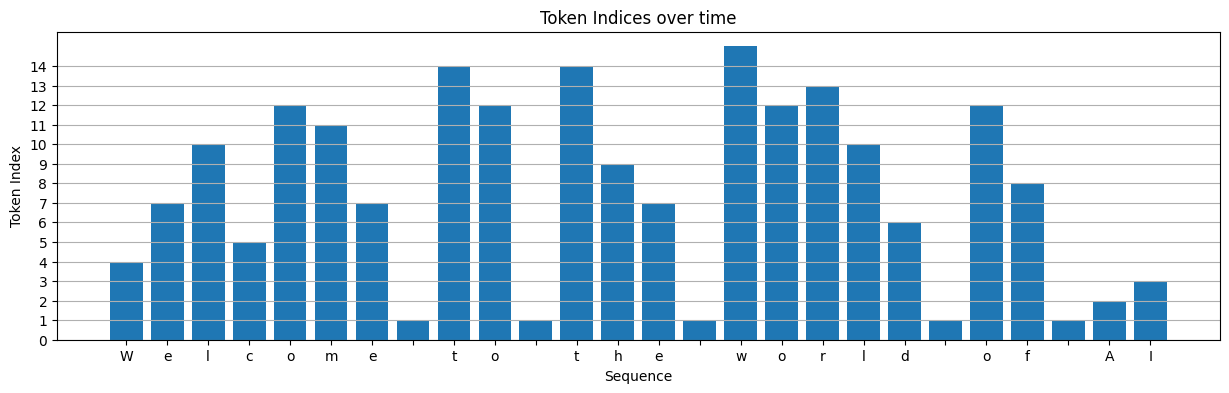

In [40]:
# Let us visualize above
def plot_token_indices(tokens, title='Token Indices over time'):
    '''
    tokens: np.array of shape (B, T)
    '''
    assert tokens.shape[0] == 1, f'We are working with 1 full row'
    t = np.arange(tokens.shape[1])
    plt.figure(figsize=(15,4))
    plt.title(title)
    plt.bar(x=t, height=tokens[0])
    plt.xticks(ticks=range(0, len(cfg.text),1), labels=cfg.text)
    plt.yticks(ticks=range(0,15,1))
    plt.ylabel('Token Index')
    plt.xlabel('Sequence')
    plt.grid(axis='y')
    plt.show()


# Test the function
plot_token_indices(tokens=tokens)

Above shows our sequence and the index positions for each token. For example, we see that w has a value of 4, e has a value of 6, space has a value of 0, etc.

With this in place, let's work on our core numerical primitives. 

### Stable Softmax / Cross-entropy from logits / LayerNorm / Dropout / GELU   

First up 
### Softmax.
Softmax is a core activation function used in machine learning tasks. It is used to convert the outputs - usually the raw logits - into a probability distribution. We setup our Softmax via a function. We also consider numerical stability as we build this out.

In [41]:
# Setup a numerically stable implementation of softmax
def softmax_stable(logits, axis=-1):
    '''
    Numerically stale softmax implementation
    logits: np.array(..., D) D Is vocab size
    '''

    # First up find the max value in the logits
    max_logits = np.max(logits, axis=axis, keepdims=True)

    # Shift the logits by the max
    shifted = logits - max_logits
    exp_shifted = np.exp(shifted)
    probs = exp_shifted / np.sum(exp_shifted, axis=axis, keepdims=True)
    return probs

# Suppress scientific notation
np.set_printoptions(suppress=True)

# Test the function
tmp_logits = np.array([-2., 3, 1, 5, -4])
softmax_stable(tmp_logits)

array([0.00078972, 0.11720525, 0.01586201, 0.86603615, 0.00010688])

Cool we seem to have a stable Softmax. Lets plot Softmax and also see the impact temperature can have on the probabilities. We learned a lot about temperature, top_p and top_k in the first post in this series:**Welcome to the world of AI  - Understanding temperature, top_p and top_k**

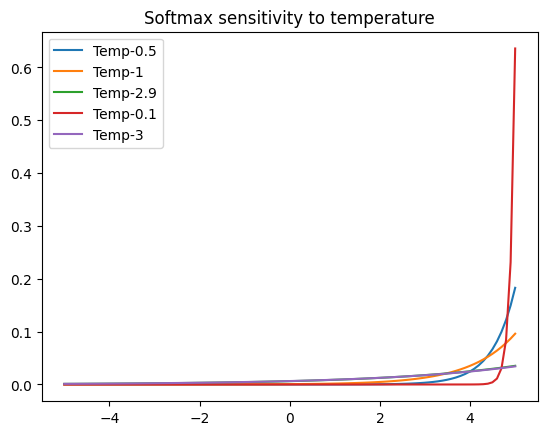

In [42]:
# Create a 100 evenly spaced points between -5 and +5
x = np.linspace(-5, 5, 100)
for temp in [0.5, 1, 2.9, 0.1, 3]:
    probs = softmax_stable(x/temp)
    plt.plot(x, probs, label=f'Temp-{temp}')

plt.legend()
plt.title('Softmax sensitivity to temperature');

# We see below that the lower the temperature the sharper the distribution
# The higher the temperature the flatter the distribution

What we see above, is that a lower temperature results in sharper probabilities. Larger temperature, results in flatter probability distributions. As mentioned, we learned alot about temperature, top_p and top_k in the first post in this series: **Welcome to the world of AI  - Understanding temperature, top_p and top_k**

We need to be very careful here as even though we went through the process to make this numerically stable, we still have a situation where if these values are too "large" this Softmax output can - or should I say will - converge to a one-hot vector.

As you see below, once the values are "large" Softmax converges to a one-hot vector.

In [43]:
# Here is an example of that concern.
softmax_stable(np.array([-20., 30, 100, 50, -4]))

array([0., 0., 1., 0., 0.])

Well Softmax converging to a one-hot vector is not the only problem we have here.  The other problem is if we take the naive Softmax. We can already see large values causes overflow. Hence we see the *inf* below

In [44]:
a = np.array([-20., 30, 1000, 50, -4])
np.exp(a)

/tmp/ipykernel_157535/1527753011.py:2: RuntimeWarning: overflow encountered in exp
  np.exp(a)


array([2.06115362e-09, 1.06864746e+13,            inf, 5.18470553e+21,
       1.83156389e-02])

When we try to compute the Softmax using the naive method. We see that we have additional overflows and nan values.Hence the reason why we need to ensure we are using the stable method.

In [45]:
# Overflow and nans
np.exp(a) / np.sum(np.exp(a), axis=-1, keepdims=True)

/tmp/ipykernel_157535/844943855.py:2: RuntimeWarning: overflow encountered in exp
  np.exp(a) / np.sum(np.exp(a), axis=-1, keepdims=True)
/tmp/ipykernel_157535/844943855.py:2: RuntimeWarning: invalid value encountered in divide
  np.exp(a) / np.sum(np.exp(a), axis=-1, keepdims=True)


array([ 0.,  0., nan,  0.,  0.])

Let us now jump to the 
### Cross-entropy loss   
If you are doing anything with classification in neural networks, you are more than likely using cross-entropy loss. If you are doing binary classification, you are more than likely using Binary Cross-entropy. For a multi-class problem, you may be using Categorical Cross-entropy or maybe Sparse Categorical Cross-entropy. All different flavours of Cross-entropy loss.

Let us build a Cross entropy function

In [46]:
# Cross entropy loss
def cross_entropy_loss(logits, targets):
    '''
    logits: (B, T, vocab_size)
    targets: (B, T)
    Returns scalar loss. Single value
    '''
    B, T, V = logits.shape
    probs = softmax_stable(logits=logits, axis=-1)

    # Now let us get the log probability at those index positions
    log_probs = np.log(probs[np.arange(B)[:, None], np.arange(T)[None, :], targets  ])
    loss = -np.mean(log_probs)

    return loss

# The function
targets = np.array([0,1,1,0,1])
logits = np.array([-2., 3, 1, 5, -4])

cross_entropy_loss(logits=logits.reshape(1, 1, -1), targets=targets)

np.float64(4.143828630781675)

The result of Cross-entropy is a single (scalar) value that tells us how well the model is learning. The closer this loss is to 0, the higher the model accuracy. So the objective is to minimize the loss.

### LayerNorm    
https://arxiv.org/pdf/1607.06450     

While this might seem as only being used for normalization, LayerNorm is also used to condition the residual update scale.    

Normalization also helps with speeding up the training process. Layer normalization is done on a per record - single training example - case. This normalization method uses the same technique at training time and test time. 

In [47]:
# With the loss calculated, let us setup LayerNorm
class LayerNorm:
    def __init__(self, d_model, eps=1e-5):
        self.d_model = d_model
        self.eps = eps

        # The scale and bias will be learned
        self.gamma = np.ones((d_model,), dtype=np.float32)
        self.beta = np.zeros((d_model,), dtype=np.float32)

    def __call__(self, x):
        '''
        x: (B, T, d_model)
        '''
        mean = np.mean(x, axis=-1, keepdims=True)
        var = np.var(x, axis=-1, keepdims=True)

        # Perform standardization
        x_hat = (x - mean) / np.sqrt(var + self.eps)

        # Do the scaling and shifting
        out = self.gamma * x_hat + self.beta
        
        return out

Let us now visualize this

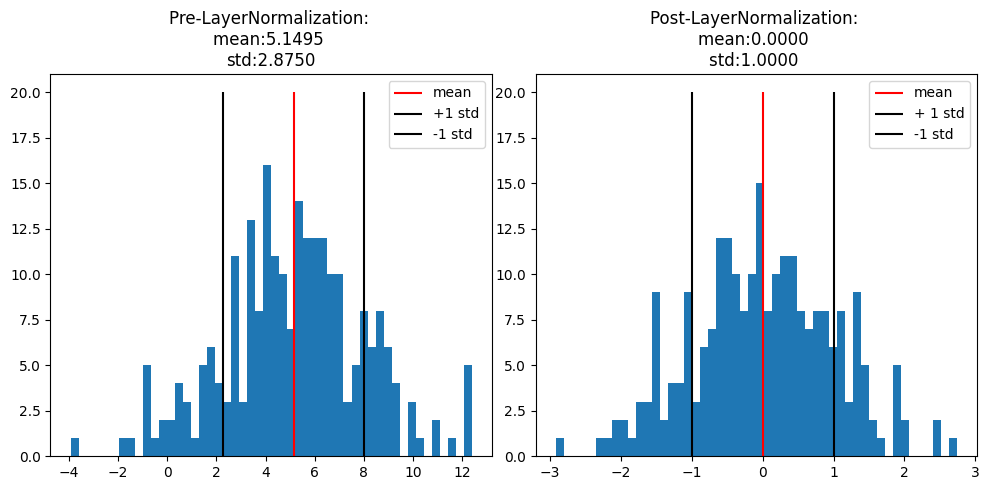

In [48]:
# Set the seed for repeatability
np.random.seed(10)
B, T, D = 1, vocab_size, cfg.d_model
x = np.random.randn(B, T, D).astype(np.float32) * 3.0 + 5.0 # Just shift and scale a bit
ln = LayerNorm(d_model=D)
y = ln(x)

# Flatten x
x_flat = x.reshape(-1, D)
y_flat = y.reshape(-1, D)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title(f'Pre-LayerNormalization: \nmean:{x_flat.flatten().mean():.4f} \nstd:{x_flat.flatten().std():.4f}')
plt.hist(x=x_flat.flatten(), bins=50)
plt.vlines(x=x_flat.flatten().mean(), ymin=0, ymax=20, label='mean', color='r')
plt.vlines(x=x_flat.flatten().mean() + x_flat.flatten().std() * 1, ymin=0, ymax=20, label='+1 std', color='k')
plt.vlines(x=x_flat.flatten().mean() + x_flat.flatten().std() * -1, ymin=0, ymax=20, label='-1 std', color='k')


plt.legend()

plt.subplot(1,2,2)
plt.title(f'Post-LayerNormalization: \nmean:{y_flat.flatten().mean():.4f} \nstd:{y_flat.flatten().std():.4f} ')
plt.hist(x=y_flat.flatten(), bins=50)
plt.tight_layout()
plt.vlines(x=y_flat.flatten().mean(), ymin=0, ymax=20, label='mean', color='r')
plt.vlines(x=y_flat.flatten().mean() + (1 * y_flat.flatten().std()), ymin=0, ymax=20, label='+ 1 std', color='k')
plt.vlines(x=y_flat.flatten().mean() - (1 * y_flat.flatten().std()), ymin=0, ymax=20, label='-1 std', color='k')

plt.legend()
plt.show()

Without LayerNorm, we have a mean of 5.1 on the left and a standard deviation of 2.9. On the right we have a mean of 0 and a standard deviation of 1. This is what we typically want when training our models.

With LayerNorm in place and its visualization, let's see what Dropout is about

### Dropout   
https://www.cs.toronto.edu/~rsalakhu/papers/srivastava14a.pdf    

Dropout is a regularization strategy that is used to address overfitting. Dropout - disable - neurons during training of the neural network.

Overfitting is a term you will hear alot about in machine learning. It is where the model has learned not only the patterns in the data but potentially the noise also. Thus while the model may train and have an accuracy of 100% and a loss of 0, during inference time, the model is quite inconsistent. That is to say the model will have high variance and low bias. 

Dropout is one mechanism used to address overfitting. It is what is called a regularization strategy.

In [49]:
# Setup our dropout class
class Dropout:
    def __init__(self, p=0.1):
        self.p = p
        self.training = True

    def __call__(self, x):
        if not self.training or self.p == 0:
            return x
        mask = ( np.random.rand(*x.shape) > self.p).astype(x.dtype)

        # Implement invert dropout: scale by 1/(1-p) at train time only
            
        return mask * x / (1.0 - self.p)


In [50]:
B, T, D = (1, 5, 4)
x = np.ones((B, T, D), dtype=np.float32)
print(x)

# Setup dropout
do = Dropout(p=0.5)

# Set training to True
do.training = True

print(f'0.5 dropout:\n{do(x)}')

# Disable dropout
do.training = False
do(x)

[[[1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]
  [1. 1. 1. 1.]]]
0.5 dropout:
[[[2. 0. 2. 0.]
  [2. 2. 0. 0.]
  [2. 0. 0. 0.]
  [0. 2. 0. 2.]
  [2. 2. 2. 2.]]]


array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]]], dtype=float32)

Now that we have an understanding of dropout, let's go ahead and wrap this up with th Gaussian Error Linear Unit (GELU) activation function 

### GELU  - Gaussian Error Linear Unit
https://arxiv.org/pdf/1606.08415   

GELU is considered to be a high performance activation function. Activation functions are what introduces the non-linearity in neural networks. It weights inputs by their values. GELU also includes property from dropout and ReLU. 


In [51]:
# Define GELU
def gelu(x):
    '''
    This is the approximate version using Tanh
    x: np.array
    '''
    return 0.5 * x * (
        1.0 + np.tanh(
            np.sqrt(2.0 / np.pi) * (x + 0.044715 * (x**3) )
        )
    )

# Test the functio
x = np.linspace(-4, 4, 400)

# Implement ReLU so we can compare
y_relu = np.maximum(0, x)
y_gelu = gelu(x)


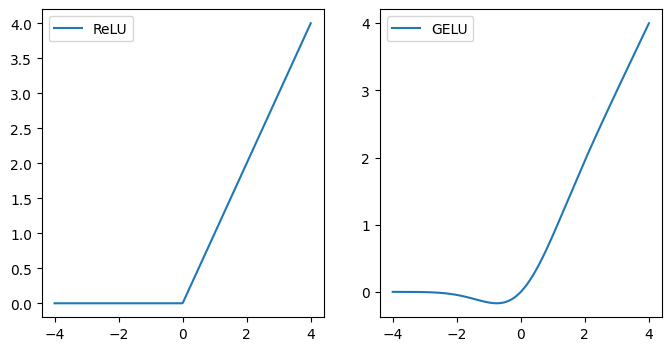

In [52]:
# plot GELU
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.plot(x, y_relu, label='ReLU')
plt.legend()

plt.subplot(122)
plt.plot(x, y_gelu, label='GELU')
plt.legend()
plt.show()

We can see above that while ReLU puts everything below 0 to exactly 0, this is not the case with GELU. With GELU, small negative values are possible while large negative values are clipped at 0. 

We have most of the tools we need so far to move ahead with building our model. Let's move on to Token Embeddings and Learned Positional Encodings.

the positional embeddings will have shape (max_seq_len, d_model).
Each position (time step) will have a trainable vector.  

In our case, our token embeddings will be (vocab_size, d_model)

Our initial residual stream will be 
residual = token_embed + pos_embed  


### Token Embeddings and Learned Positional Encodings 

In [55]:
# Setup an embedding class
class Embeddings:
    def __init__(self, vocab_size, d_model, max_len):
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_len = max_len

        # Our token embeddings will be: (vocab_size, d_model)
        # We will also use this for weight tying strategy later when setting up our Language Model (LM) Head
        self.W_tok = (np.random.randn(vocab_size+1, d_model) / np.sqrt(d_model) ).astype(np.float32)

        # Learned positional embeddings: (max_len, d_model)
        self.W_pos = (np.random.randn(max_len, d_model) / np.sqrt(d_model) ).astype(np.float32)


    def __call__(self, x):
        '''
        x: (B, T) our integer token indices 
        Returns: residual stream (B, T, d_model)
        '''
        B, T = x.shape
        assert T <= max_len, f'Sequence length: {T} is greater than max len: {self.max_len} '
        
        # Setup the token embeddings
        tok_emb = self.W_tok[x] # (B, T, d_model)

        # Setup the positional embeddings
        pos_emb = self.W_pos[None, :T, :] # (1, T, d_model) - This is for broadcasting

        residual = tok_emb + pos_emb

        return residual, tok_emb, pos_emb

# Just something to start with
max_len = 64

# Set a manual seed so our results are the same
np.random.seed(10)
emb = Embeddings(vocab_size=vocab_size, d_model=cfg.d_model, max_len=max_len)

# Time to build the initial residual stream from x
residual, tok_emb, pos_emb = emb(X)

# All shapes or now (1, T-1, d_model)
residual.shape, tok_emb.shape, pos_emb.shape

((1, 25, 16), (1, 25, 16), (1, 25, 16))

Cool, we setup our residual, we got our token and positional embeddings

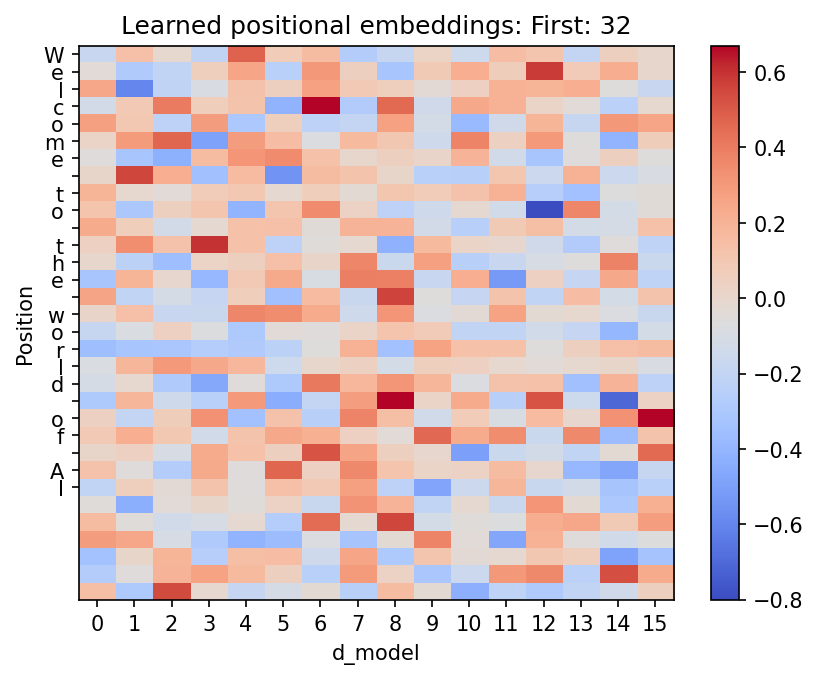

In [56]:
# Visualize the untrained positional embeddings
def plot_positional_embeddings_heatmap(W_pos, num_positions=16):
    num_positions = min(num_positions, W_pos.shape[0])
    plt.figure(dpi=150)
    plt.title(f'Learned positional embeddings: First: {num_positions}')
    plt.imshow(W_pos[:num_positions], aspect='auto', cmap='coolwarm')
    plt.colorbar()
    plt.xlabel('d_model')
    plt.ylabel('Position')
    plt.yticks(ticks=range(0, len(cfg.text),1), labels=cfg.text)
    plt.xticks(ticks=range(0, cfg.d_model, 1))
    plt.show()


plot_positional_embeddings_heatmap(emb.W_pos, num_positions=32)

At this point, we have no structure above as no learning has been done as yet.   
- Each row is a position.    
- Each column is one of our 16 embedding dimensions.   
- Notice that these are not smooth.   
- We also see roughly same variance across
- It also looks like no two positions look identical.

Think about this as our first view as the positions embedding into the tokens   

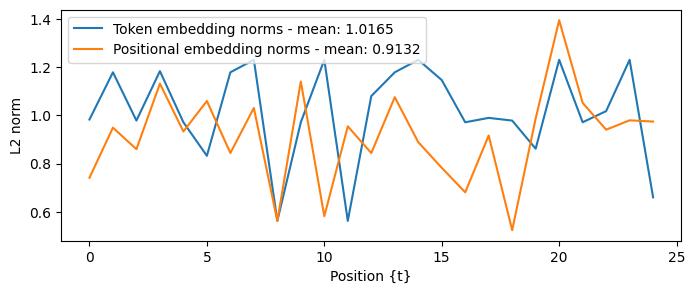

In [58]:
def plot_token_vs_pos_norms(tok_emb, pos_emb):
    '''
    tok_emb, pos_emb: (B, T, d_model)
    '''
    assert tok_emb.shape == pos_emb.shape
    B, T, D = tok_emb.shape

    tok_norms = np.linalg.norm(tok_emb, axis=-1)[0] # (T,)
    pos_norms = np.linalg.norm(pos_emb, axis=-1)[0] # (T,)

    plt.figure(figsize=(8,3))
    t = np.arange(T)
    plt.plot(t, tok_norms, label=f'Token embedding norms - mean: {tok_norms.mean():.4f}')
    plt.plot(t, pos_norms, label=f'Positional embedding norms - mean: {pos_norms.mean():.4f}')

    plt.xlabel('Position {t}')
    plt.ylabel('L2 norm')


    plt.legend()
    plt.show()


# Test the function
plot_token_vs_pos_norms(tok_emb, pos_emb)

Our data has d_model = 16 dimensions at this time. We cannot visualize this, so let's leverage PCA to bring this data down.    
We see the average mean norm is about the same. This means they are about the same scale    
If the positional norms are too small, the model may struggle to learn     
At the same time, we don't want the positional embeddings to be too large. We do not wish to overwhelm the token identity    
What we want is a balanced representation. This looks somewhat balanced when we look at the mean    

We could leverage sklearn's PCA but let's build our own just for the fun of it.

In [59]:
# Setup 
def pca_2d(x):
    '''
    x: (n_rows, d_dimensions)
    Returns: (N, 2)
    '''
    x_mean = x.mean(axis=0, keepdims=True)
    x_centered = x - x_mean
    cov = x_centered.T @ x_centered / (x_centered.shape[0] - 1)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx[:2]]  # (D, 2)

    return x_centered @ eigvecs # (N, 2)

# Test the function
pca_2d(tok_emb.reshape(-1, 16))[:5]

array([[ 0.255776  ,  0.23570058],
       [-0.9714201 ,  0.5525704 ],
       [-0.19787998,  0.3391831 ],
       [-0.63930357,  0.12790056],
       [-0.07901763, -0.9264408 ]], dtype=float32)

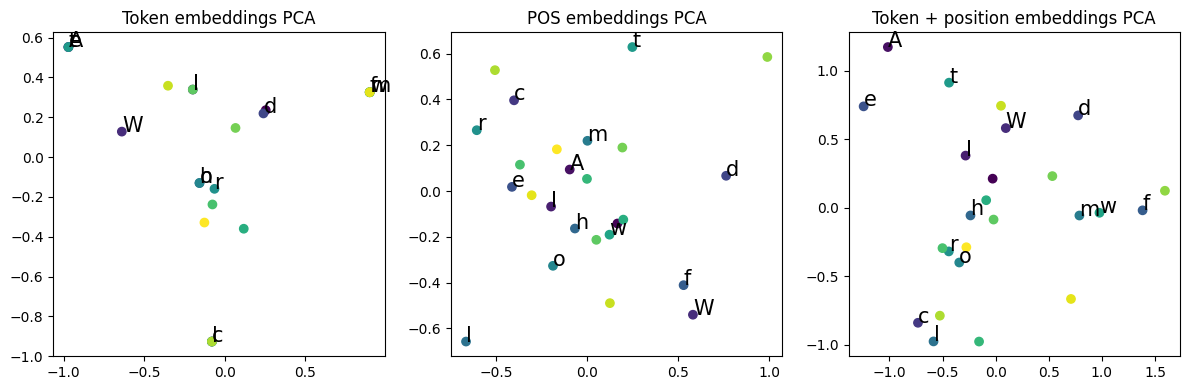

In [60]:
# Let's visualize this now
def plot_pca_token_vs_token_plus_pos(tok_emb, pos_emb):
    '''
    Compare geometry of token embeddings vs token + pos
    '''
    B, T, D = tok_emb.shape

    # Reshape the embeddings for PCA
    # We have three dimensions but only need 2
    tok_flat = tok_emb.reshape(B*T, D)
    pos_flat = pos_emb.reshape(B*T, D)
    tok_pos_flat = (tok_emb + pos_emb).reshape(B*T, D)

    # Leverage PCA
    tok_pca = pca_2d(tok_flat)
    pos_pca = pca_2d(pos_flat)
    tok_pos_pca = pca_2d(tok_pos_flat)

    plt.figure(figsize=(12,4))
    plt.subplot(131)
    plt.title('Token embeddings PCA')
    plt.scatter(tok_pca[:, 0], tok_pca[:, 1], c=np.arange(T).repeat(B), cmap='viridis')

    for idx, ch in enumerate(chars):
            plt.text(tok_pca[idx, 0], tok_pca[idx, 1], s=ch, fontsize=15)

    plt.subplot(132)
    plt.title('POS embeddings PCA')
    plt.scatter(pos_pca[:, 0], pos_pca[:, 1], c=np.arange(T).repeat(B), cmap='viridis')

    for idx, ch in enumerate(chars):
            plt.text(pos_pca[idx, 0], pos_pca[idx, 1], s=ch, fontsize=15)

    plt.subplot(133)
    plt.title('Token + position embeddings PCA')
    plt.scatter(tok_pos_pca[:, 0], tok_pos_pca[:, 1], c=np.arange(T).repeat(B), cmap='viridis')

    for idx, ch in enumerate(chars):
            plt.text(tok_pos_pca[idx, 0], tok_pos_pca[idx, 1], s=ch, fontsize=15)

    plt.tight_layout()
    plt.show()


plot_pca_token_vs_token_plus_pos(tok_emb, pos_emb)

What should we take away from these images above. Here are a few things:
1. Transformer encodes some structure, even before we interact with attention or the feed forward network.
2. We want to know how adding the position embeddings change the geometry of the token embeddings

Let us move on to a masked single head attention. We will do the mask single head before moving to multi-head attention.

### Single Head Masked self-attention mechanism   
We have our residual (token_embeddings + positional_embeddings) with shape (1,25, 16)
At this point we have (B, T, d_model) in the end this will be (B, T, d_head). Remember we will only have one head to start, so d_head will equal to d_model.

In [61]:
# Define a he single head attention
def single_head_attention(x, W_q, W_k, W_v):
    '''
    x: (B, T, d_model)
    W_q: (d_model, d_model)
    W_k: (d_model, d_model)
    W_v: (d_model, d_model)

    Returns:
        attn_out: (B, T, d_model)
        attn_weights: (B, T, T)
        scores_raw: (B, T, T)
        scores_masked: (B, T, T)
    '''

    # Get the shape
    B, T, D = x.shape

    # perform the projections to Q, K, V
    Q = x @ W_q # (B, T, d_model)
    K = x @ W_k # (B, T, d_model)
    V = x @ W_v # (B, T, d_model)

    # With the projections in place, 
    # let get scaled dot-product attention scores
    scores_raw = (Q @ K.transpose(0,2,1)) / np.sqrt(cfg.d_model) # (B, T, T)

    # Setup the causal mask
    mask = np.triu(np.ones((T, T), dtype=bool), k=1)
    scores_masked = scores_raw.copy()
    scores_masked[:, mask] = -1e9   # (B, T, T)

    # Softmax
    attn_weights = softmax_stable(scores_masked, axis=-1) # (B, T, T)

    # Get the weighted values
    attn_out = attn_weights @ V # (B, T, d_model)

    return attn_out, attn_weights, scores_raw, scores_masked

In [62]:
# disable scientific notation
np.set_printoptions(suppress=True)

# Setup the weight matricies 
# We scale the initial weights here by 0.02, just to make them a bit smaller to help the training
# We are basically scaling the standard deviation here so it is closer to 0 with ~0.02 std
W_q = np.random.randn(cfg.d_model, cfg.d_model).astype(np.float32) * 0.02
W_k = np.random.randn(cfg.d_model, cfg.d_model).astype(np.float32) * 0.02
W_v = np.random.randn(cfg.d_model, cfg.d_model).astype(np.float32) * 0.02

# test the function
attn_out, attn_weights, scores_raw, scores_masked = single_head_attention(residual, W_q , W_k, W_v)

# Confirm the shapes
print(f'Residua shape: {residual.shape} -> (B, T, d_model)')
print(f'Attn out shape: {attn_out.shape} -> (B, T, d_model)')
print(f'Attn weights shape: {attn_weights.shape} -> (B, T, T)')
print(f'Scores raw shape: {scores_raw.shape} -> (B, T, T) ')
print(f'Scores masked shape: {scores_masked.shape} -> (B, T, T)')

print(f'W_q mean: {W_q.mean():.4f} | W_q std: {W_q.std():.4f}')

Residua shape: (1, 25, 16) -> (B, T, d_model)
Attn out shape: (1, 25, 16) -> (B, T, d_model)
Attn weights shape: (1, 25, 25) -> (B, T, T)
Scores raw shape: (1, 25, 25) -> (B, T, T) 
Scores masked shape: (1, 25, 25) -> (B, T, T)
W_q mean: -0.0002 | W_q std: 0.0189


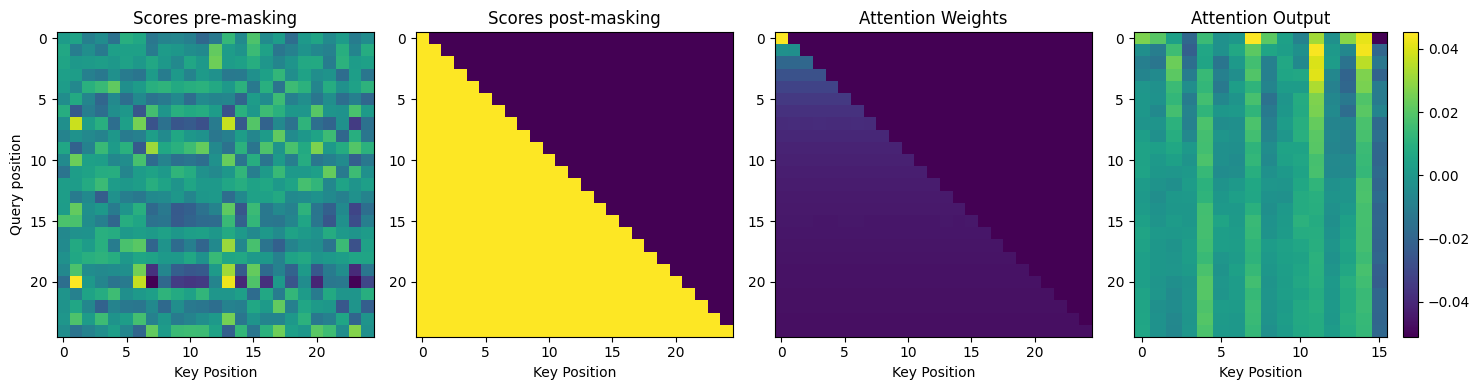

In [63]:
plt.figure(figsize=(15,4))

plt.subplot(141)
plt.imshow(scores_raw[0], aspect='auto', cmap='viridis')
plt.title('Scores pre-masking')
plt.xlabel('Key Position')
plt.ylabel('Query position')

plt.subplot(142)
plt.imshow(scores_masked[0], aspect='auto')
plt.title('Scores post-masking')
plt.xlabel('Key Position')
#plt.ylabel('Query position')

plt.subplot(143)
plt.imshow(attn_weights[0], aspect='auto', cmap='viridis')
plt.title('Attention Weights')
plt.xlabel('Key Position')
#plt.ylabel('Query position')

plt.subplot(144)
plt.imshow(attn_out[0], aspect='auto', cmap='viridis')
plt.title('Attention Output')
plt.xlabel('Key Position')
#plt.ylabel('Query position')

plt.colorbar()
plt.tight_layout()
plt.show()

**Pre-masking**
For the pre-masking, the query is the row and the column is the key   
We still do not have any structure as yet in the pre-masking plot   
right now, each token is most likely similar to itself   
This represents the unrestricted attention landscape   
We can conclude this is how the model would attend if there was no autoregressive behaviour   
This is the raw nature of the residual stream    

**Post-masking** 
What do we take away from the post-masking.   
Keep in mind, this is the same matrix as the pre-masking. Only difference now is the upper triangle has been replaced with -inf   
The mask prevents the model from looking to the future   
Every token can only attend to itself and the tokens preceding it. 
This is the core idea behind autoregressive generation

**Attention weights**  
This now says where each token looks   
Position 0 can only attend to itself  
Earlier positions distribute the attention across earlier tokens  
Think about this as a routing mechanism where the attention flows across the sequences  
This is the model communicating with itself

**Attention output**
Finally, we have the attention output  


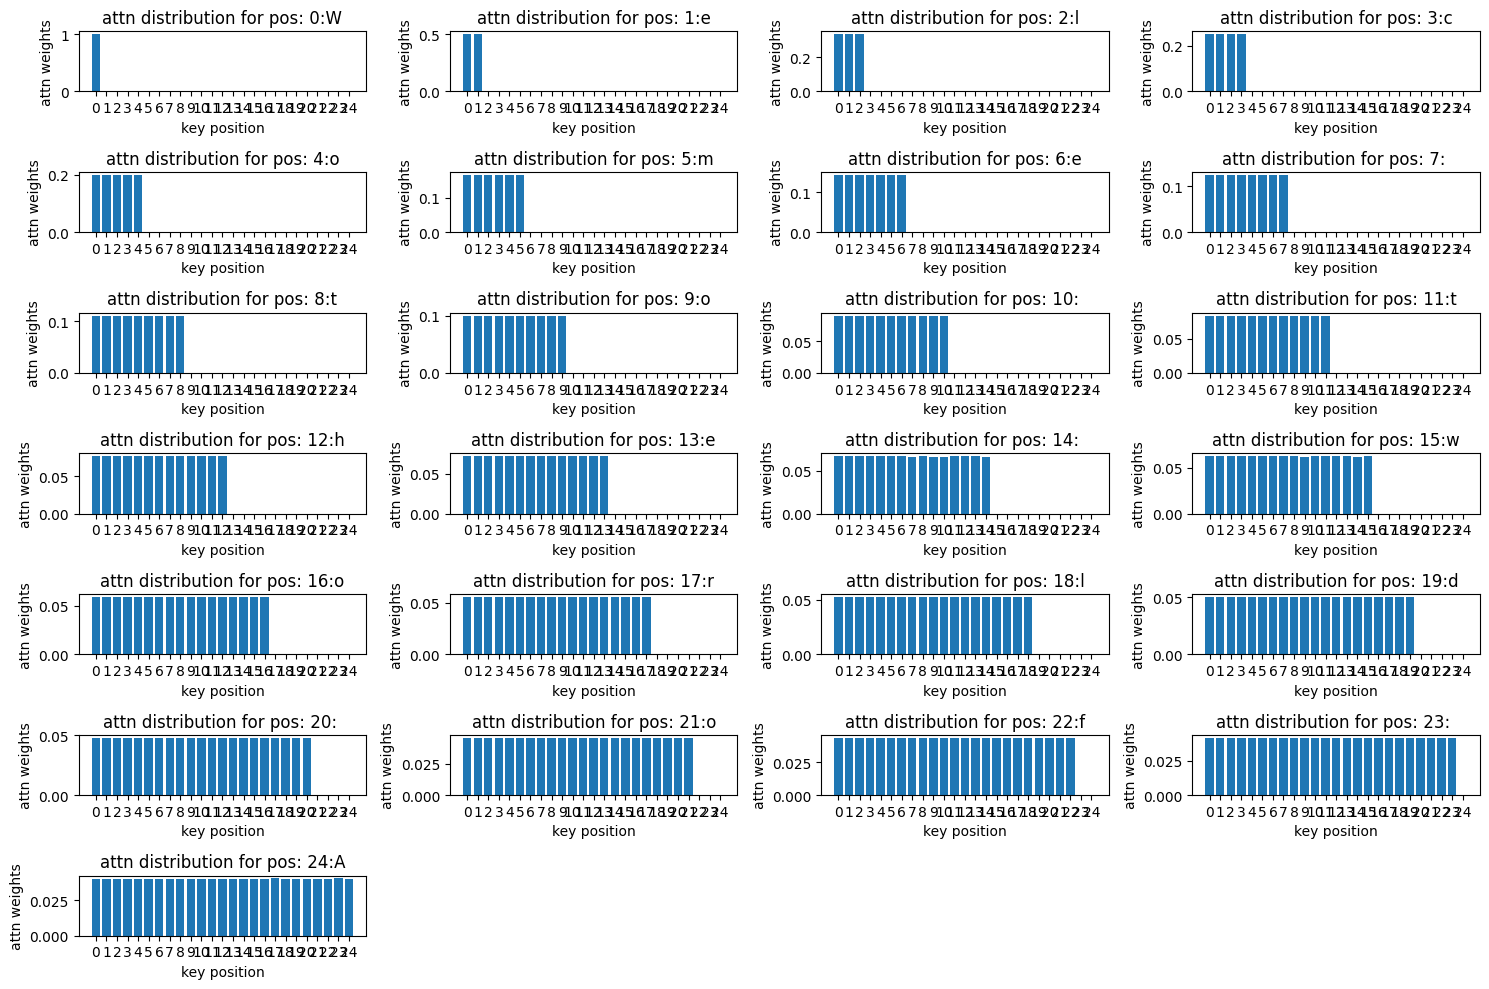

In [64]:
# Plot the per attention weights
attn_weights.shape

# Get the shape data
B, T, d_model = attn_weights.shape

# Get the bar plot
plt.figure(figsize=(15,10))
for i in range(28):
    plt.subplot(7, 4,i+1)
    plt.bar(np.arange(T), attn_weights[0, i])
    plt.title(f'attn distribution for pos: {i}:{cfg.text[i]}')
    plt.xlabel('key position')
    plt.ylabel('attn weights')
    plt.xticks(ticks=range(0,25,1))
    if i == attn_weights.shape[1] - 1:
        break

plt.tight_layout()
#plt.bar(np.arange(T), attn_weights[0, 10])

What do you take away from above.
The one bar in the first plot, means that the model can only attend to the first token. Basically itself.    
For position 5 for example, the model can only attend to positions 0-4. These values sum to 1 for the probabilities  
Some positions may strongly prefer one earlier token   
Overall, we can look at attention as a probability distribution. From a local perspective the model is attending to nearby tokens. From the global perspective the model attends broadly. It is self-focused when the model attends mostly to itself.

Plot the update norm to the residual. Visualize once again.


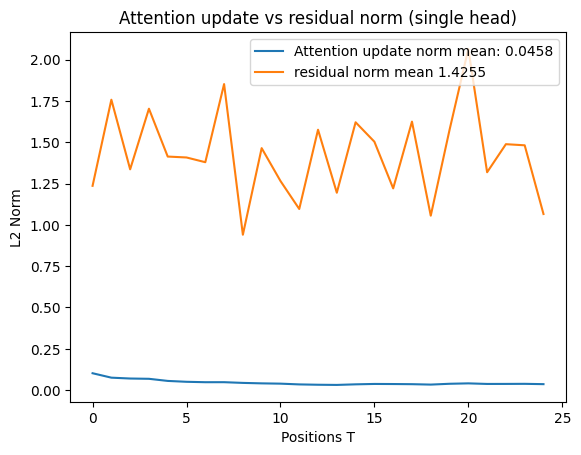

In [65]:
# We have a larger residual norm than the update norm
# This is what we want 
upd_norms = np.linalg.norm(attn_out[0], axis=-1)
res_norms = np.linalg.norm(residual[0], axis=-1)

plt.plot(np.arange(T), upd_norms, label=f'Attention update norm mean: {upd_norms.mean():.4f}')
plt.plot(np.arange(T), res_norms, label=f'residual norm mean {res_norms.mean():.4f}')
plt.xlabel('Positions T')
plt.ylabel('L2 Norm')
plt.title("Attention update vs residual norm (single head)")

plt.legend()
plt.show()

Think of attention as an additive update not a replacement. 
The update is usually small relative to the residual stream 


Now that we understand how a single attention head works, let us move on to multi-head attention.

### Multi-head attention  


In [66]:
# Let us do this via a class
class MultiHeadSelfAttention:
    def __init__(self, d_model, n_heads, dropout_p=0.0):
        # Let us ensure that the d_model is divisible by n_heads
        assert d_model % n_heads == 0, f'd_model: {d_model} not divisible by n_heads: {n_heads}'

        self.d_model = d_model

        # Each head shares the same input 
        # but will see different subspaces hence difference perspectives
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        # Using one QKV projection: (d_model, 3*d_model)
        # This approach is also more efficient
        self.W_qkv = (np.random.randn(d_model, 3 * d_model) * 0.02).astype(np.float32)

        # Also setup our input projection
        # We need this to fuse the heads back together
        # Fuse the information from the different heads together
        self.W_o = (np.random.randn(d_model, d_model) * 0.002).astype(np.float32)

        # Setup dropout
        self.dropout = Dropout(p=dropout_p)

    def __call__(self, x):
        '''
        x> (B, T, d_model)
        returns:
        out: (B, T, d_model)
        attn_weights: (B, n_heads, T, T)
        '''
        # Capture the shape information
        B, T, D = x.shape

        # do our first linear projection to QKV
        qkv = x @ self.W_qkv # (B, T, 3*d_model)

        # 3 is included below for the each of the QKV
        qkv = qkv.reshape(B, T, 3, self.n_heads, self.d_head) # (B, T, 3, n_heads, d_head)

        # Transpose the dimensions
        qkv = np.transpose(qkv, axes=(2, 0, 3, 1, 4)) # (3, B, n_heads, T, d_head)

        # Extract the Q, K, V
        # Each of these now have a shape of (B, n_heads, T, d_head )
        Q, K, V = qkv[0], qkv[1], qkv[2]

        # Scaled dot-product attention per head
        # shape (n_heads, T, T)
        scores = (Q @ K.transpose(0, 1, 3, 2)) / np.sqrt(self.d_head)

        # Setup the causal mask
        mask = np.triu(np.ones((T, T), dtype=bool), k=1) # (T,T)
        scores_masked = scores.copy()
        scores_masked[:, :, mask] = -1e9

        # Apply softmax 
        attn_weights = softmax_stable(scores_masked, axis=-1) # (B, n_heads, T, T)

        # Get the weighted sum of values
        attn_out = attn_weights @ V # (B, n_heads, T, d_head)

        # Let us put these heads back together
        attn_out = attn_out.transpose(0, 2, 1, 3).reshape(B, T, self.d_model)   # (B, T, d_model)

        # Final output projection from the attention mechanism
        out = attn_out @ self.W_o # (B, T, d_model)

        # Let's add a dropout if needed
        out = self.dropout(out)

        return out, attn_weights, scores, scores_masked

In [ ]:
# Test the class
mha = MultiHeadSelfAttention(d_model=cfg.d_model, n_heads=cfg.n_heads)

mha_out, mha_attn_weights, mha_scores_raw, mha_scores_masked = mha(x=residual)

# confirming the shapes we saw above
mha_out.shape, mha_attn_weights.shape, mha_scores_raw.shape, mha_scores_masked.shape

((1, 25, 16), (1, 4, 25, 25), (1, 4, 25, 25), (1, 4, 25, 25))

With the output from the multi-head self-attention, let us visualize some of the items we retrieved.

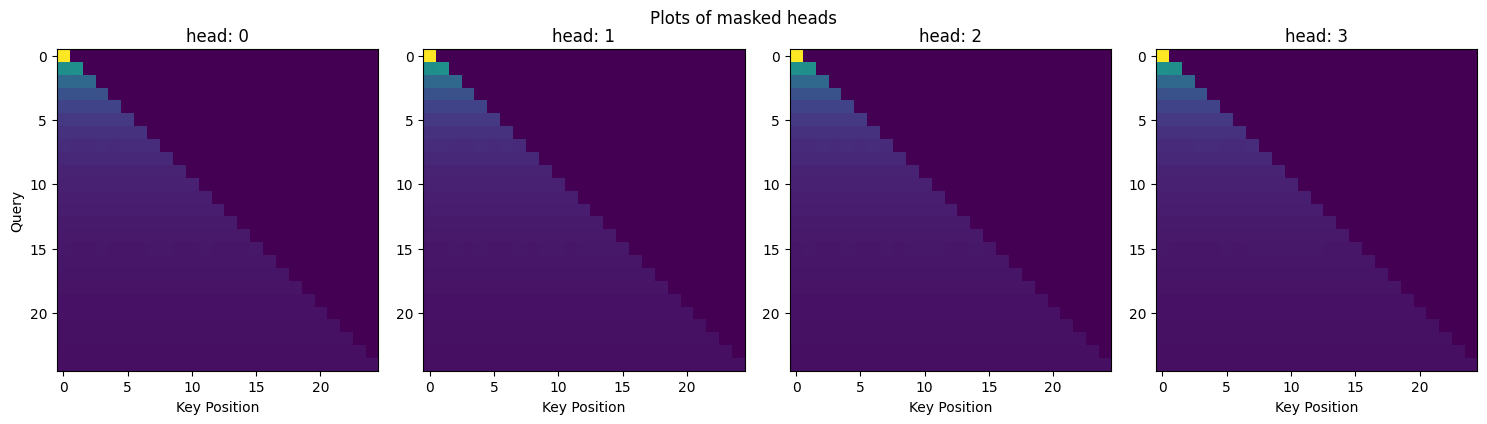

In [68]:
plt.figure(figsize=(15,4))
plt.suptitle('Plots of masked heads')
for i in range(cfg.n_heads):
    plt.subplot(1,4,i+1)
    plt.imshow(mha_attn_weights[0, i], cmap='viridis')
    plt.title(f'head: {i}')
    plt.xlabel('Key Position')
    if i == 0:
        plt.ylabel('Query')

plt.tight_layout()

Remember this model has not been trained as yet, hence as we move from the first row (query) down to the last row, the probabilities are more diffused. This is why the colours move from bright above to seemingly the same as you go further down.

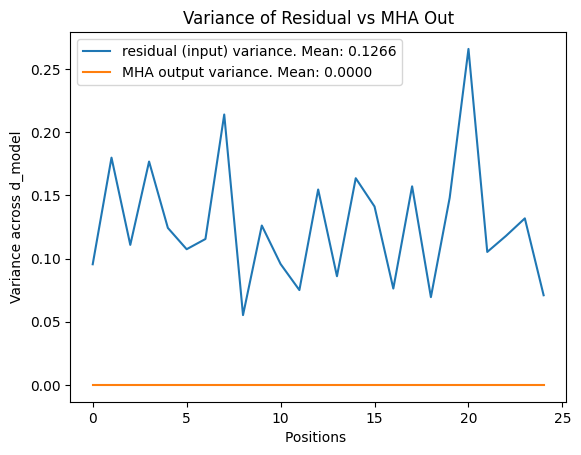

In [69]:
# Plot the output variance
# We see the residual var is larger than the MHA out variance

residual_var = residual[0].var(axis=-1)
mha_out_var = mha_out[0].var(axis=-1)

B, T, D = residual.shape
t = np.arange(T)

plt.plot(t, residual_var, label=f'residual (input) variance. Mean: {residual_var.mean():.4f}')
plt.plot(t, mha_out_var, label=f'MHA output variance. Mean: {mha_out_var.mean():.4f}')
plt.xlabel('Positions ')
plt.ylabel('Variance across d_model')
plt.title('Variance of Residual vs MHA Out')
plt.legend()
plt.show()

We have the multi-head self-attention mechanism in place. Let's move on to the feed forward network (FFN).  

### Feed Forward  
The FFN is where the computation occurs
This FFN is position wise. There is no mixing across the time dimension

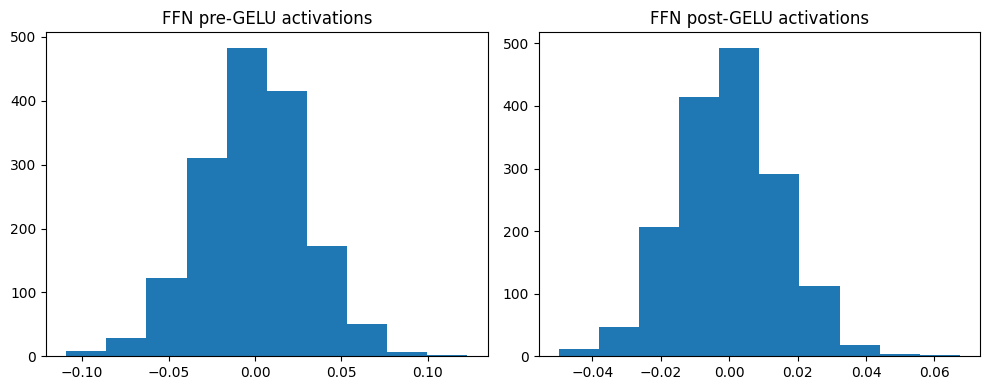

In [70]:
class FeedForward:
    def __init__(self, d_model, ffn_expansion=4, dropout_p=0.0):
        '''
        ffn_expansion=4: 4 * d_model
        '''
        self.d_model = d_model
        self.d_hidden = ffn_expansion * d_model

        # Our first linear projection
        self.W1 = (np.random.randn(d_model, self.d_hidden)*0.02).astype(np.float32)
        self.b1 = np.zeros((self.d_hidden,), dtype=np.float32)

        # Our second linear projection
        self.W2 = (np.random.randn(self.d_hidden, self.d_model)*0.02).astype(np.float32)
        self.b2 = np.zeros((self.d_model,), dtype=np.float32)

        # Setup dropout
        self.dropout = Dropout(p=dropout_p)

    def __call__(self, x):
        '''
        x: (B, T, d_model)
        returns: (B, T, d_model)
        '''

        # Apply the first linear layer
        h = x @ self.W1 + self.b1 # (B, T, d_hidden)

        # Apply the activation function
        h = gelu(h) 

        # Final linear projection and get the output of the ffn
        out = h @ self.W2 + self.b2 # (B, T, d_model)

        # Apply dropout if available
        out = self.dropout(out)

        return out


# Test the function
ffn = FeedForward(d_model=cfg.d_model)

# Realistically, we should test this on the output of the MHA
# ffn(mha_out).shape, 

# Let's test it on our residual, the original input
ffn(residual).shape

# Visualization of the effects of the FFN on the input
ffn_pre_activation = residual@ ffn.W1 + ffn.b1
ffn_post_activation = gelu(ffn_pre_activation)

plt.figure(figsize=(10,4))
plt.subplot(121)
plt.title('FFN pre-GELU activations')
plt.hist(ffn_pre_activation.flatten())

plt.subplot(122)
plt.title('FFN post-GELU activations')
plt.hist(ffn_post_activation.flatten())

plt.tight_layout()
plt.show()


Above, we see the impact the activation function has on the input.

Let's take a scatter plot 

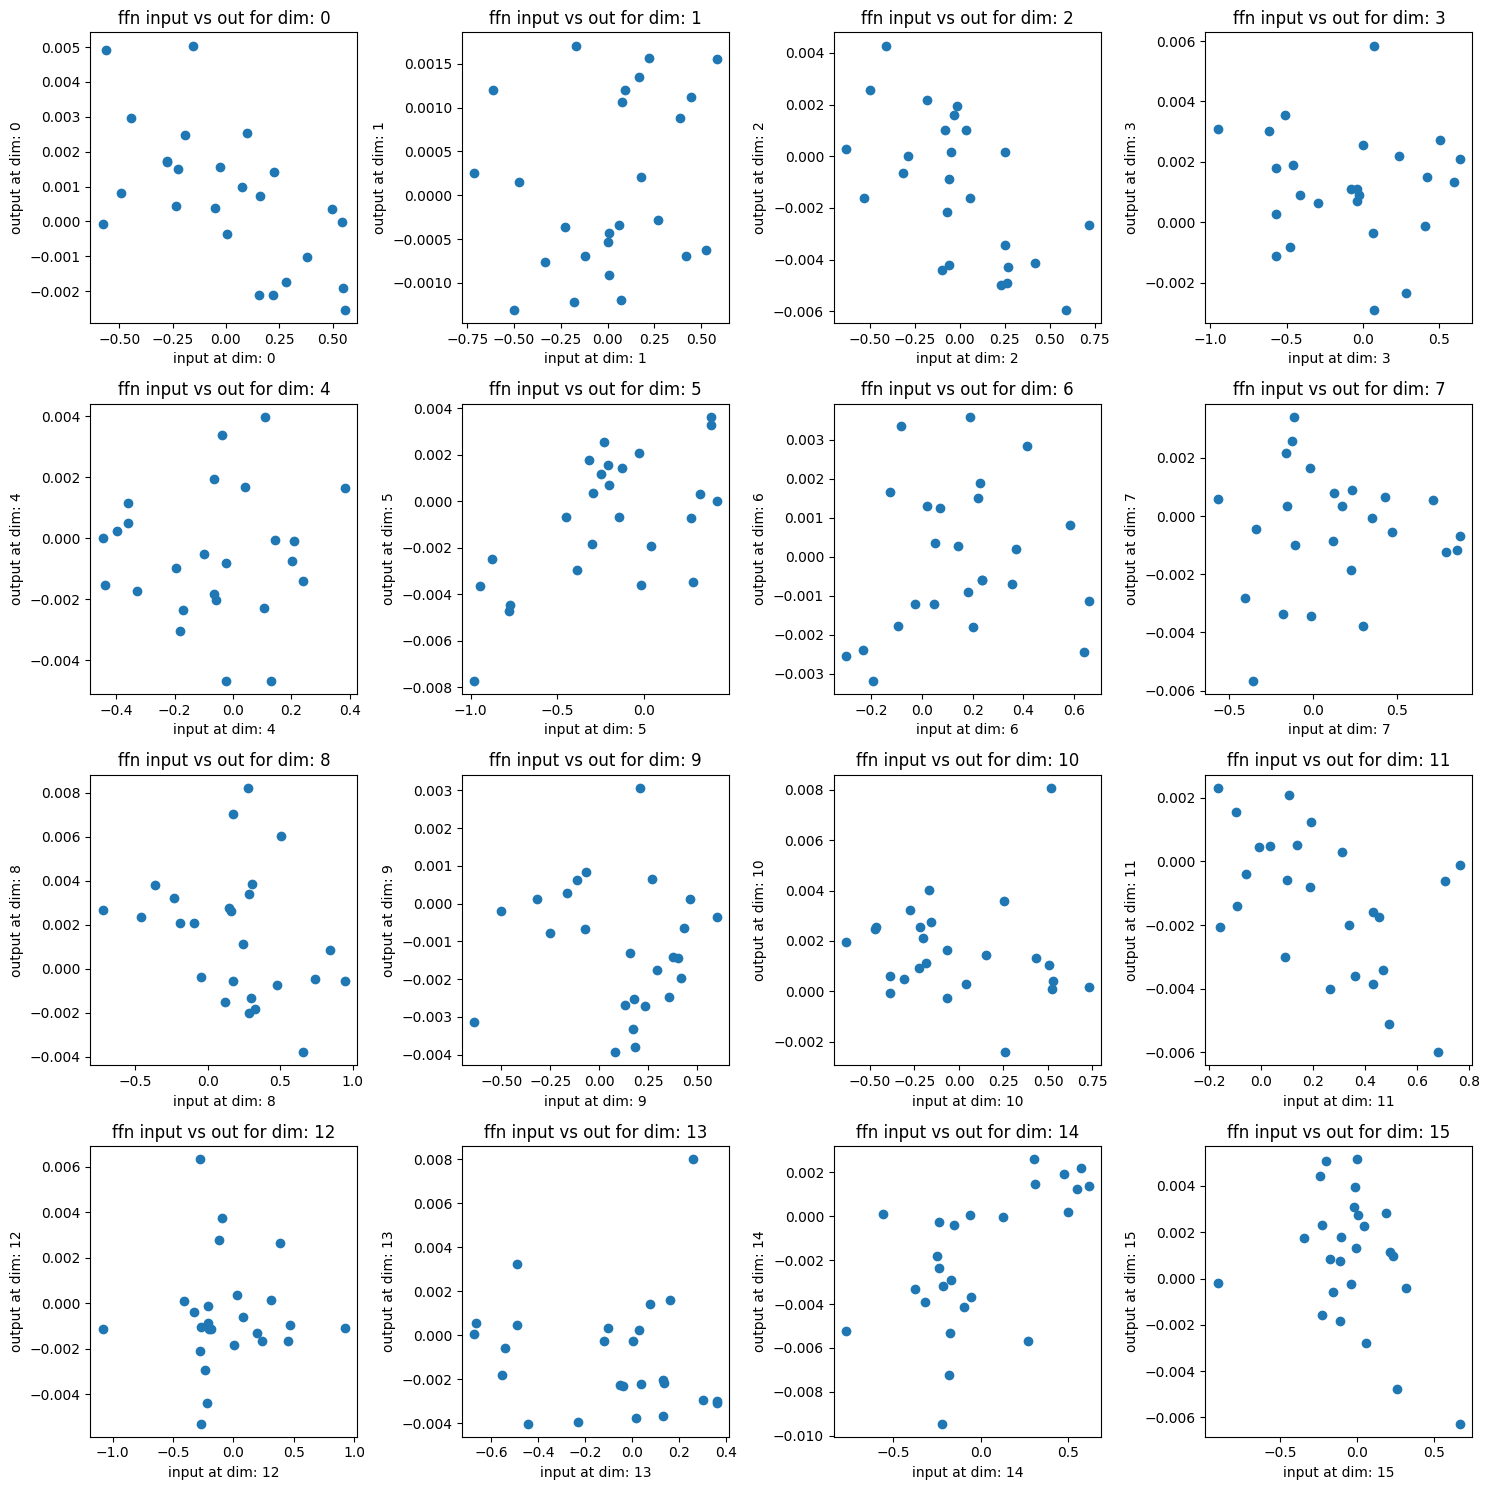

In [71]:
x_flat = residual.reshape(-1, cfg.d_model)
y_flat = ffn(residual).reshape(-1, cfg.d_model)

plt.figure(figsize=(15,15))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.scatter(x_flat[:, i ], y_flat[:, i])
    plt.title(f'ffn input vs out for dim: {i}')
    plt.xlabel(f'input at dim: {i}')
    plt.ylabel(f'output at dim: {i}')
    
plt.tight_layout()

One take away from here is how the FFN reshapes the input vectors

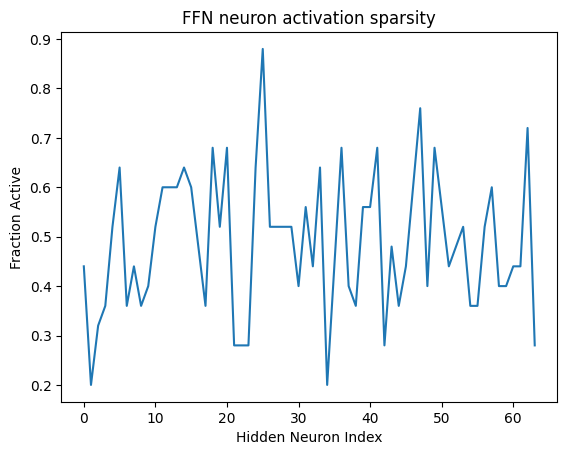

In [72]:
# Remember when we called GELU some neurons will become 0
# Let's calculate how many of those neurons are 0s
sparsity = np.mean(ffn_post_activation > 0, axis=(0,1))

plt.title(f'FFN neuron activation sparsity')
plt.plot(sparsity)
plt.xlabel('Hidden Neuron Index')
plt.ylabel('Fraction Active');

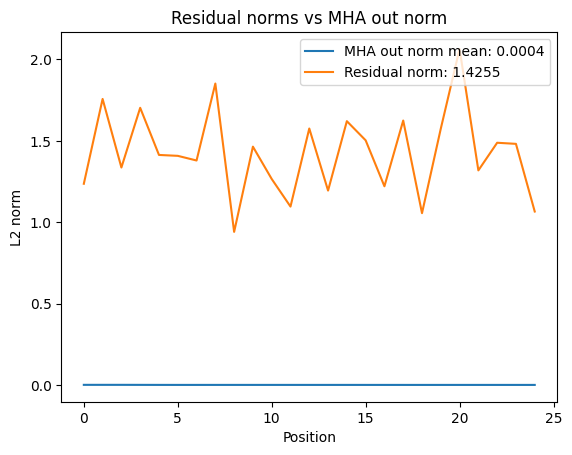

In [73]:
# Get the norms
residual_norms = np.linalg.norm(residual[0], axis=-1)
out_norm = np.linalg.norm(mha_out[0], axis=-1)

plt.plot(t, out_norm, label=f'MHA out norm mean: {out_norm.mean():.4f}')
plt.plot(t, residual_norms, label=f'Residual norm: {residual_norms.mean():.4f}')
plt.title(f'Residual norms vs MHA out norm')
plt.xlabel('Position')
plt.ylabel('L2 norm')

plt.legend()

With all of this in place let's go ahead and put it all together. 
We will use our pre LayerNorm
residual connection
MHA + FFN combined

Basically, let us put together a decoder block
### Decoder Block


In [74]:
class DecoderBlock:
    def __init__(self, d_model, n_heads, ffn_expansion=4, attn_dropout=0.0, ffn_dropout=0.0):
        # Setup the layer norms
        self.ln1 = LayerNorm(d_model=d_model)
        self.ln2 = LayerNorm(d_model=d_model)

        # Setup MHA
        self.mha = MultiHeadSelfAttention(d_model=d_model, n_heads=cfg.n_heads, dropout_p=attn_dropout)

        # Setup the FFN
        self.ffn = FeedForward(d_model=d_model, ffn_expansion=ffn_expansion, dropout_p=ffn_dropout)

    def __call__(self, x):
        '''
        residual: (B, T, d_model)
        returns:
            residual_out: (B, T, d_model)
            cache: dict of intermediates for visualizations
        '''
        cache = {}

        # MHA Block
        x_norm1 = self.ln1(x)
        mha_out, attn_weights, scores_raw, scores_masked = self.mha(x)

        # Get the residual after the MHA
        residual_mha = x + mha_out # Residual updates

        # Cache some results
        cache['x_norm1'] = x_norm1
        cache['mha_out'] = mha_out
        cache['attn_weights'] = attn_weights
        cache['scores_masked'] = scores_masked
        cache['residual_after_mha'] = residual_mha

        # FFN Block
        x_norm2 = self.ln2(residual_mha)
        ffn_out = self.ffn(x_norm2)
        residual_mha_ffn_out = residual_mha + ffn_out

        cache['x_norm2'] = x_norm2
        cache['ffn_out'] = ffn_out
        cache['residual_mha_ffn_out'] = residual_mha_ffn_out

        return residual_mha_ffn_out, cache

In [75]:
# Test the class
decoder_block = DecoderBlock(d_model=cfg.d_model, n_heads=cfg.n_heads)
decoder_out, decoder_cache = decoder_block(x=residual)
decoder_out.shape, decoder_cache.keys()

((1, 25, 16),
 dict_keys(['x_norm1', 'mha_out', 'attn_weights', 'scores_masked', 'residual_after_mha', 'x_norm2', 'ffn_out', 'residual_mha_ffn_out']))

Now that we have put together one decoder block, let's put together a stack

### Stack of Decoders

In [76]:
class DecoderStack:
    def __init__(self, n_layers, d_model, n_heads, ffn_expansion=4, attn_dropout_p=0.0, ffn_dropout_p=0.0):
        self.n_layers = n_layers
        self.blocks = [ 
            DecoderBlock(d_model=cfg.d_model, n_heads=cfg.n_heads) for _ in range(n_layers)]

    def __call__(self, x):
        '''
        x: residual (B, T, d_model)
        returns: 
            residual: (B, T, d_model)
            all_caches: list[dict] per layer
        '''
        all_caches = []

        for layer_idx, block in enumerate(self.blocks):
            x, cache = block(x)
            cache['layer_idx']  = layer_idx
            all_caches.append(cache)
        return x, all_caches

In [ ]:
# Test the stack
decoder_stack = DecoderStack(n_layers=cfg.n_layers, d_model=cfg.d_model, n_heads=cfg.n_heads)

residual_final, caches = decoder_stack(residual)
residual_final.shape, [ i.keys() for i in caches ]


((1, 25, 16),
 [dict_keys(['x_norm1', 'mha_out', 'attn_weights', 'scores_masked', 'residual_after_mha', 'x_norm2', 'ffn_out', 'residual_mha_ffn_out', 'layer_idx']),
  dict_keys(['x_norm1', 'mha_out', 'attn_weights', 'scores_masked', 'residual_after_mha', 'x_norm2', 'ffn_out', 'residual_mha_ffn_out', 'layer_idx'])])

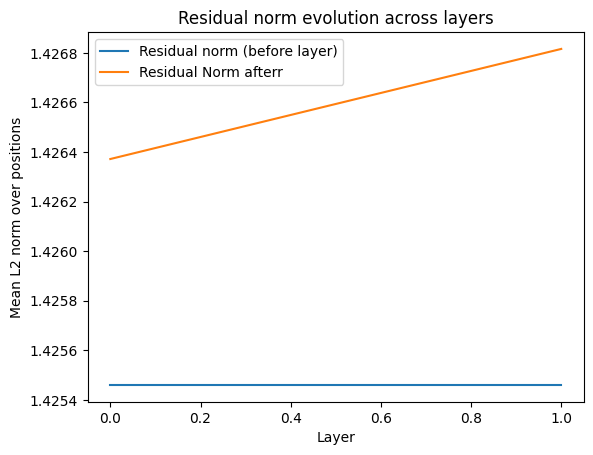

In [78]:
# Let's visualize what we just built
layer_indices = []
norms_before = []
norms_after = []

x = residual

for cache in caches:
    layer_idx = cache['layer_idx']
    res_after = cache['residual_mha_ffn_out']

    norms_before.append(np.linalg.norm(residual[0], axis=-1).mean())
    norms_after.append(np.linalg.norm(res_after[0], axis=-1).mean())
    layer_indices.append(layer_idx)
    x = res_after

plt.plot(layer_indices, norms_before, label='Residual norm (before layer)')
plt.plot(layer_indices, norms_after, label='Residual Norm afterr')
plt.xlabel('Layer')
plt.ylabel('Mean L2 norm over positions')
plt.title("Residual norm evolution across layers")
plt.legend();


In [79]:
print(f'Norms before: {norms_before}')
print(f'Norms after: {norms_after}')

Norms before: [np.float32(1.4254605), np.float32(1.4254605)]
Norms after: [np.float64(1.426371919459707), np.float64(1.4268161008242064)]


We can see above the residual stream barely changes across layers 
Residual connections add small updates 

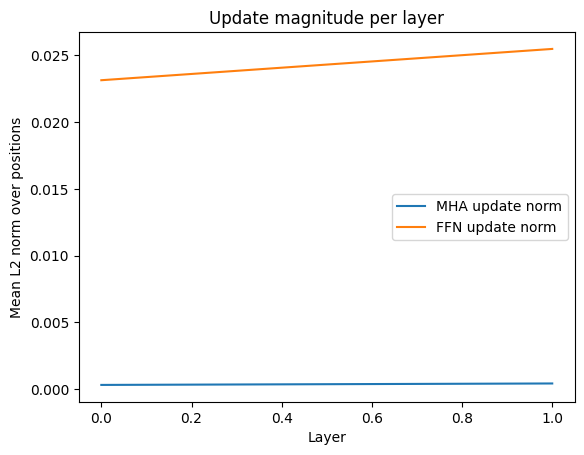

In [80]:
norms_before# Let's visualize what we just built
layers = []
mha_updates = []
ffn_updates = []
x = residual

for cache in caches:
    layer_idx = cache['layer_idx']
    res_before = x
    res_after_mha = cache['residual_after_mha']
    res_after = cache['residual_mha_ffn_out']

    mha_update = res_after_mha - res_before
    ffn_update = res_after - res_after_mha

    mha_updates.append(np.linalg.norm(mha_update[0], axis=-1).mean())
    ffn_updates.append(np.linalg.norm(ffn_update[0], axis=-1).mean())
    layers.append(layer_idx)
    x = res_after

plt.plot(layers, mha_updates, label='MHA update norm')
plt.plot(layers, ffn_updates, label='FFN update norm')
plt.xlabel('Layer')
plt.ylabel('Mean L2 norm over positions')
plt.title("Update magnitude per layer")
plt.legend();


In [ ]:
# # Create a function for cosine similarity
# def cosine(a, b):
#     num = np.sum(a * b, axis=-1)
#     den = np.linalg.norm(a, axis=-1) * np.linalg.norm(b, axis=-1) + 1e-8
#     return num/den

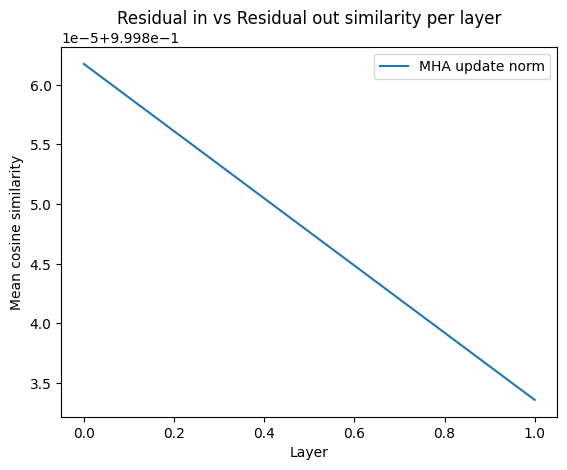

In [ ]:
# # Let now plot the cosine similarity residual
# layers = []
# cos_means = []

# x = residual.copy()

# for cache in caches:
#     layer_idx = cache['layer_idx']
#     res_before = x
#     res_after = cache['residual_mha_ffn_out']

#     cos = cosine(res_before[0], res_after[0])
#     cos_means.append(cos.mean())
#     layers.append(layer_idx)

#     x = res_after

# plt.plot(layers, cos_means, label='MHA update norm')
# plt.xlabel('Layer')
# plt.ylabel('Mean cosine similarity')
# plt.title("Residual in vs Residual out similarity per layer")
# plt.legend();

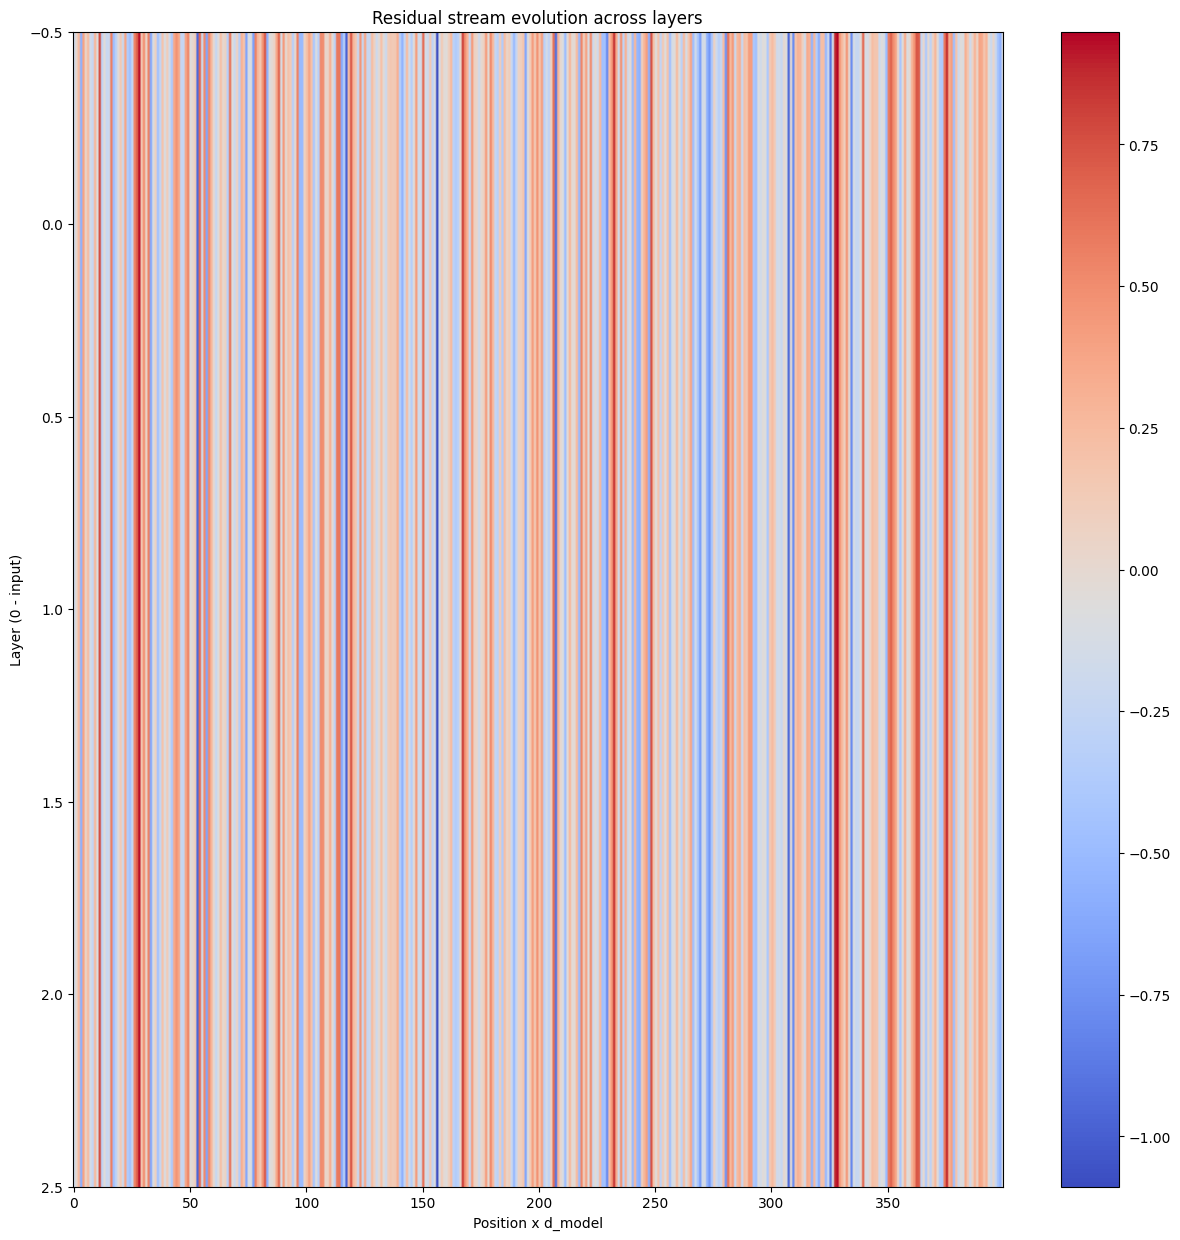

In [84]:
# Create a heatmap of the residual stream
B, T, D = residual.shape

activations = [residual[0]]
x = residual.copy()

for cache in caches:
    x =cache['residual_mha_ffn_out']
    activations.append(x[0])

activations = np.stack(activations, axis=0)
Lp1 = activations.shape[0]

plt.figure(figsize=(15,15))
plt.imshow(activations.reshape(Lp1, T * D ), aspect='auto', cmap='coolwarm')
plt.xlabel('Position x d_model')
plt.ylabel('Layer (0 - input)')
plt.title("Residual stream evolution across layers")
plt.colorbar();


Above, we are visualizing the entire residual stream for all layers 
We have a model at 16 dimensions. We have 0-25 positions 16*26. Hence the reason for the 400 points above.
Think about this as seeing how the model's internal representation evolves as it goes deeper. 
We see similar patters across rows

Let us move ahead with setting up the language head, softmax and loss ..

### LM Head   
We will use the weight tying approach

In [85]:
class LMHead:
    def __init__(self, W_tok):
        '''
        W_tok: (vocab_size, d_model)
        We reuse tok embeddings as output weights (weight tying)
        '''
        self.W_out = W_tok # (vocab_size, d_model)

    def __call__(self, x):
        '''
        residual: (B, T, d_model)
        returns: logits: (B, T, vocab_size)        
        '''
        B, T, D = x.shape
        V, D2 = self.W_out.shape

        #(B, T, D) @ (D, vocab_size) -> (B, T, vocab_size)
        logits = x @ self.W_out.T

        return logits

# Test the function
lmh = LMHead(W_tok=emb.W_tok)

logits = lmh(residual_final)
logits.shape

(1, 25, 16)

In [ ]:
# With the logits let's go ahead and get the probabilities 
out_preds = np.argmax(logits, axis=-1)[0]

# Here is our prediction for our untrained model
''.join([ itos[i] for i in out_preds])

Well at this point, we could calculate the loss and backpropagate, etc. However, the objective was to build a transformer, not train a transformer. I think we have achieved this objective. 

To train a transformer, we will take an easier route. 

In [ ]:
# Put it all together
class DecoderOnlyTransformer:
    def __init__(self, d_model, n_heads, n_layers, dropout_p, W_tok):
        self.decoder_stack = DecoderStack(n_layers=n_layers, d_model=d_model, n_heads=n_heads)
        self.lm_head = LMHead(W_tok=W_tok)
        
    def __call__(self, x):
        x, _ = self.decoder_stack(x)
        x = self.lm_head(x)
        return x

# Setup the full Decoder only transformer
transformer = DecoderOnlyTransformer(d_model=cfg.d_model, n_heads=cfg.n_heads, n_layers=cfg.n_layers, dropout_p=0.0, W_tok=emb.W_tok)

# Get the logits
logits = transformer(residual)
logits.shape

In [ ]:
# With the logits let's go ahead and get the probabilities 
out_preds = np.argmax(logits, axis=-1)[0]

# Here is our generation for our untrained model
''.join([ itos[i] for i in out_preds])

'Welco e fo ohe world of A'

Well that's it for this second post in this series. If you find something I could have or should have done differently, let me know.   
Let us do this with Torch now and leverage Andrej Karpathy's makemore series to generate new baby names. To learn more about this series, check out: https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ